In [2]:
import yfinance as yf

In [3]:
sp500 = yf.Ticker("^GSPC")

In [4]:
sp500 = sp500.history(period="max")

In [5]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,0.0,0.0
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,0.0,0.0
2025-07-24 00:00:00-04:00,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,0.0,0.0


In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-07-15 00:00:00-04:00', '2025-07-16 00:00:00-04:00',
               '2025-07-17 00:00:00-04:00', '2025-07-18 00:00:00-04:00',
               '2025-07-21 00:00:00-04:00', '2025-07-22 00:00:00-04:00',
               '2025-07-23 00:00:00-04:00', '2025-07-24 00:00:00-04:00',
               '2025-07-25 00:00:00-04:00', '2025-07-28 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24508, freq=None)

<Axes: xlabel='Date'>

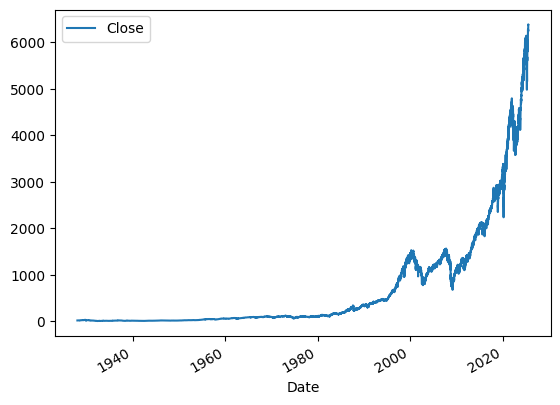

In [9]:
sp500.plot.line(y="Close", use_index=True)

In [14]:
del sp500["Dividends"]

KeyError: 'Dividends'

In [12]:
del sp500["Stock Splits"]

In [16]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [17]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,6358.910156
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,6363.350098
2025-07-24 00:00:00-04:00,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,6388.640137


In [22]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
#target is "1" if tomorrow's price increased and "0" if it decreased

In [19]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,6358.910156,1
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,6363.350098,1
2025-07-24 00:00:00-04:00,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,6388.640137,1


In [24]:
#removes all rows before Jan 1, 1990
sp500 = sp500.loc["1990-01-01":].copy()

In [25]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,6358.910156,1
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,6363.350098,1
2025-07-24 00:00:00-04:00,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,6388.640137,1


In [34]:
from sklearn.ensemble import RandomForestClassifier
#Random forest are more resistent to overfitting

# Incerased n_esitmators improves accuracy up to a cetain point. 
# min_samples_split helps stop overfitting but decreases accuracy
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
RandomForestClassifier(min_samples_split=100, random_state=1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
from sklearn.metrics import precision_score
# How accurate was the model when predicting "Target" if it will go up (percent)

preds = model.predict(test[predictors])

In [40]:
import pandas as pd

In [41]:
preds = pd.Series(preds, index=test.index)

In [44]:
precision_score(test["Target"], preds)

0.5789473684210527

In [45]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

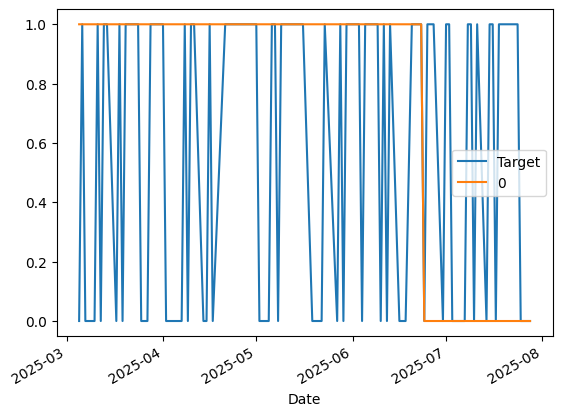

In [46]:
combined.plot()

In [49]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict(test[predictors]) #generates predictions
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [52]:
def backtest(data, model, predictors, start=2500, step=250): #start=2500 means train the first model with 10 years of data
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [53]:
predictions = backtest(sp500, model, predictors)

In [55]:
predictions["Predictions"].value_counts()

Predictions
0    3726
1    2732
Name: count, dtype: int64

In [57]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5281844802342606

In [59]:
predictions["Target"].value_counts() / predictions.shape[0] #this is the actual percentange of if it went up or down


Target
1    0.536854
0    0.463146
Name: count, dtype: float64

In [61]:
horizons = [2,5,60,250,1000] #calc mean close price in the last 2 days, 5 days, 3 months, etc...
new_predictors = []

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500 ["Close"] / rolling_average["Close"]

    trend_column =f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [63]:
sp500 = sp500.dropna()

In [64]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-21 00:00:00-04:00,6304.740234,6336.080078,6303.790039,6305.600098,5010840000,6309.620117,1,1.000699,1.0,1.003846,3.0,1.056992,38.0,1.086018,142.0,1.322543,529.0
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,6358.910156,1,1.000319,2.0,1.002384,4.0,1.055234,38.0,1.086153,142.0,1.322856,530.0
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,6363.350098,1,1.003891,2.0,1.007168,4.0,1.061012,38.0,1.094033,143.0,1.332643,531.0


In [66]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [67]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict_proba(test[predictors])[:,1] #gives the probability of the stock going up
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [68]:
predictions = backtest(sp500, model, new_predictors)

In [69]:
predictions["Predictions"].value_counts()

Predictions
0.0    4588
1.0     869
Name: count, dtype: int64

In [71]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5742232451093211